In [9]:
import pandas as pd
from pathlib import Path

# 1 - General

In [10]:
csv_path = Path("../data/raw/AB_NYC_2019.csv")

df = pd.read_csv(csv_path)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [11]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [ ]:
df = df.dropna(subset=["name", "host_name"])

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                 10037
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [13]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [16]:
df["last_review"] = pd.to_datetime(df["last_review"])
df["has_review"] = df["last_review"].notna()

In [17]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
has_review                            0
dtype: int64

# Outliners check

In [19]:
df.duplicated().sum()

0

In [20]:
df["price"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count    48858.000000
mean       152.740309
std        240.232386
min          0.000000
1%          30.000000
5%          40.000000
25%         69.000000
50%        106.000000
75%        175.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64

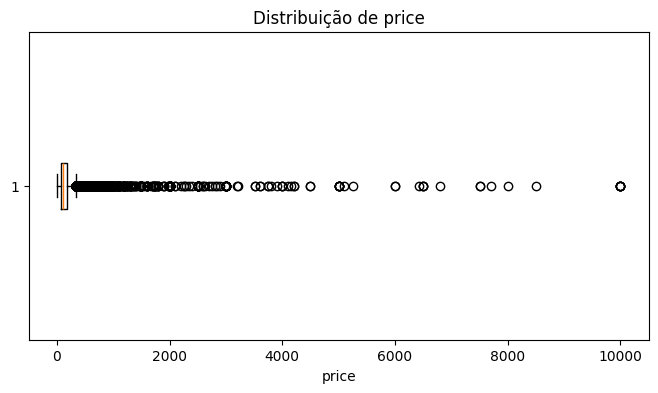

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df["price"], vert=False)
plt.title("Price Distribution")
plt.xlabel("price")
plt.show()

In [23]:
print((df["price"] == 0).sum())
print((df["price"] > 799).sum())

11
474


In [24]:
df = df[df["price"] > 0]
df["is_luxury"] = df["price"] > 799